In [1]:
from pathlib import Path
import sys

# Allows the notebook to import files from the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
from src.preprocessing import load_csv, preprocess_data
from src.instantaneous_methods import (
    velocity_magnitude_method,
    velocity_acceleration_method,
    energy_method,
    work_method, paddle_method,
)

In [3]:
file_path = PROJECT_ROOT / "data" / "LogAllData07-06_15-54-30.csv"

df = load_csv(file_path)
data = preprocess_data(df, do_savgol=True)

In [6]:
results = {
    "Velocity Magnitude": velocity_magnitude_method(data),

    "Energy": energy_method(
        data,
        hand_mass=0.4,
        kinetic_weight=0.85,
    ),

    "Work": work_method(
        data,
        hand_mass=0.4,
    ),

    "Paddle" : paddle_method(
        data,
    ),

}

Plotting

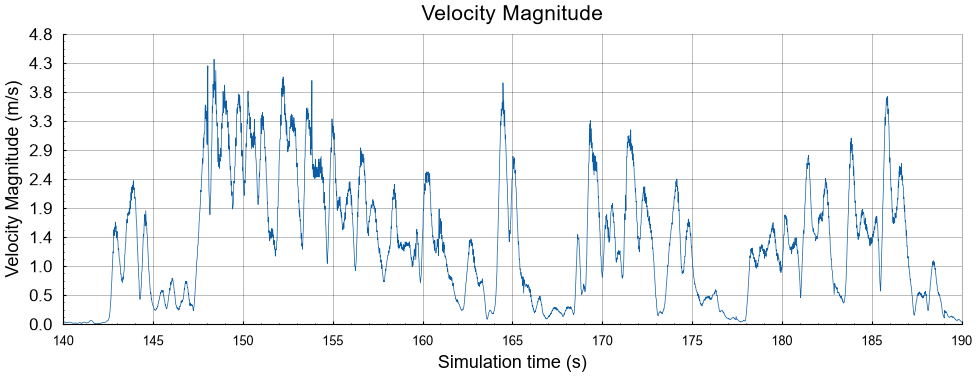

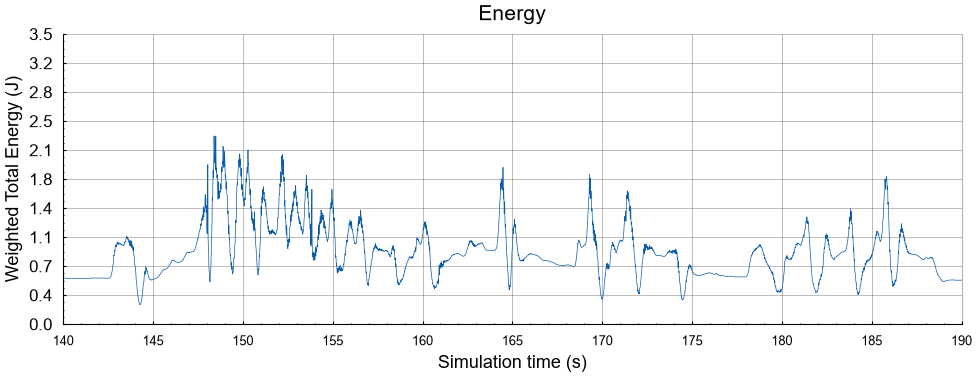

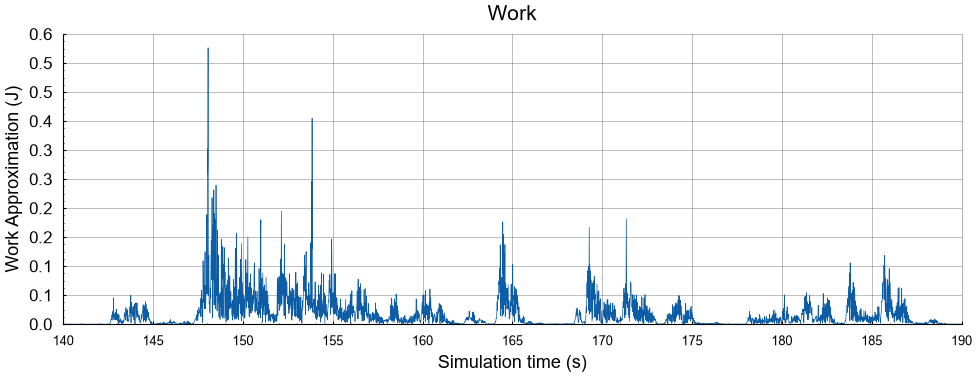

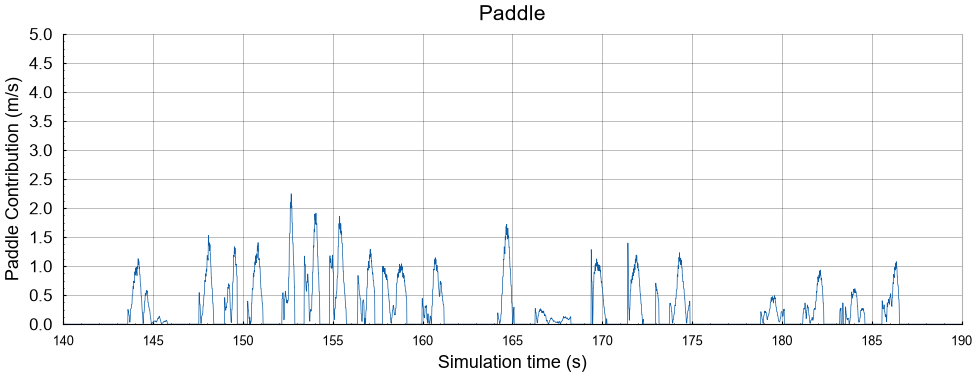

In [7]:
from matplotlib.ticker import LinearLocator, StrMethodFormatter
import scienceplots
# Reusable preferences for line plots and bar plots
from formatting_options import plot_style

# Plot range
t_1 = 140
t_2 = 190

plot_start_time = max(t_1, data["time"][0])
plot_end_time = min(t_2, data["time"].max())

if plot_start_time >= plot_end_time:
    raise ValueError("plot_start_time must be less than plot_end_time.")

with plt.style.context(["science", "notebook", "grid", plot_style]):

    for method_name, (vals, units) in results.items():

        method_time = data["time"][:len(vals)]

        fig, ax = plt.subplots(figsize=(10, 4))

        ax.plot(method_time, vals)

        # Plot-specific limits and tick placement
        ax.set_xlim(plot_start_time, plot_end_time)

        ax.xaxis.set_major_locator(LinearLocator(11))
        ax.yaxis.set_major_locator(LinearLocator(11))

        ax.xaxis.set_major_formatter(
            StrMethodFormatter("{x:.0f}")
        )
        ax.yaxis.set_major_formatter(
            StrMethodFormatter("{x:.1f}")
        )

        #format
        ax.spines["top"].set_alpha(0.3)
        ax.spines["right"].set_alpha(0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.tick_params(which='both', top=False, right=False)

        ax.set_ylim(bottom=0)

        # Plot-specific labels
        ax.set_xlabel("Simulation time (s)")
        ax.set_ylabel(units)
        ax.set_title(method_name)

        fig.tight_layout()
        plt.show()